In [48]:
import pandas as pd
import numpy as np
import sklearn as sc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import BaggingClassifier, StackingClassifier, GradientBoostingClassifier, \
    HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [49]:
df = pd.read_csv('data.csv')
df.head()

,process.b1.capacity,process.b2.capacity,process.b3.capacity,process.b4.capacity,property.price,property.product,property.winner,verification.result,verification.time
0,0,0,2,1,59,1,0,False,163.316667
1,0,0,2,1,59,2,0,False,200.860000
2,0,0,2,1,59,4,0,False,154.888889
3,0,0,2,1,59,6,0,False,108.640000
4,0,0,2,1,60,1,0,True,85.466667


In [50]:
df.columns = ['b1', 'b2', 'b3', 'b4', 'price', 'product', 'winner', 'result', 'time']

print(df.columns)

Index(['b1', 'b2', 'b3', 'b4', 'price', 'product', 'winner', 'result', 'time'], dtype='str')


In [51]:
df.info()

print('Number of nulls -', df.isnull().sum())
print('Stats -', df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 2043 entries, 0 to 2042
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   b1       2043 non-null   int64  
 1   b2       2043 non-null   int64  
 2   b3       2043 non-null   int64  
 3   b4       2043 non-null   int64  
 4   price    2043 non-null   int64  
 5   product  2043 non-null   int64  
 6   winner   2043 non-null   int64  
 7   result   2043 non-null   bool   
 8   time     2043 non-null   float64
dtypes: bool(1), float64(1), int64(7)
memory usage: 129.8 KB
Number of nulls - b1         0
b2         0
b3         0
b4         0
price      0
product    0
winner     0
result     0
time       0
dtype: int64
Stats -                 b1           b2           b3           b4        price  \
count  2043.000000  2043.000000  2043.000000  2043.000000  2043.000000   
mean      1.000000     2.093979     1.883994     0.587861    71.473324   
std       0.816696     0.811269     0.320310    

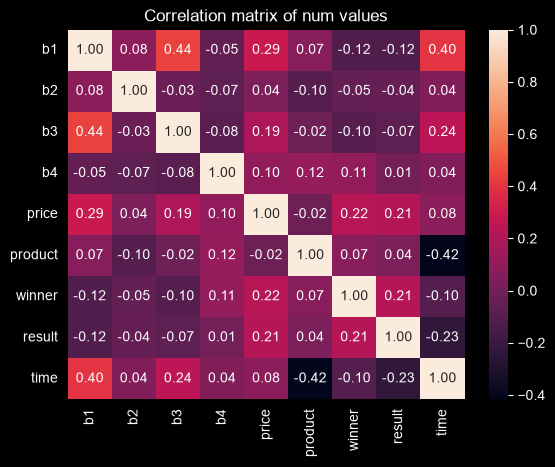

In [52]:
sns.heatmap(df.corr(), annot=True, fmt='.2f')
plt.title('Correlation matrix of num values')
plt.show()

In [53]:
capacity_cols = ['b1', 'b2', 'b3', 'b4']

df['total_capacity'] = df[['b1', 'b2', 'b3', 'b4']].sum(axis=1)
df['average_capacity'] = df[['b1', 'b2', 'b3', 'b4']].mean(axis=1)

print(df.columns)

Index(['b1', 'b2', 'b3', 'b4', 'price', 'product', 'winner', 'result', 'time',
       'total_capacity', 'average_capacity'],
      dtype='str')


In [54]:
X = df.drop(columns='result')
y = df['result']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preproc = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())])

In [56]:
X_train_scaled = preproc.fit_transform(X_train)
X_test_scaled = preproc.transform(X_test)

In [57]:
bagging = BaggingClassifier(random_state=42)
bagging.fit(X_train_scaled, y_train)

boosting = HistGradientBoostingClassifier(random_state=42)
boosting.fit(X_train_scaled, y_train)

stacking = StackingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(random_state=42)),
        ('dt', DecisionTreeClassifier(random_state=42))])
stacking.fit(X_train_scaled, y_train)

models = {'Bagging':bagging, 'Boosting':boosting, 'Stacking':stacking}

for name, model in models.items():
    predicted = model.predict(X_test_scaled)
    print('Name -', name)
    print('Accuracy -', accuracy_score(y_test, predicted))

# The Boosting and Stacking is the best, Bagging is a little bit worse

Name - Bagging
Accuracy - 0.9779951100244498
Name - Boosting
Accuracy - 0.9853300733496333
Name - Stacking
Accuracy - 0.9853300733496333
